# Projekat 3 - Sentiment Analysis pomocu vestackih neuronskih mreza

## Uvod

U ovom projektu analiziramo sentiment YouTube komentara koristeci skup podataka **YouTube Comments Dataset**.  
Zadatak pripada oblasti **analize sentimenta** i predstavlja problem **viseklasne klasifikacije**, gde je potrebno na osnovu teksta komentara predvideti da li je sentiment:

- positive
- neutral
- negative

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from collections import Counter

sns.set_theme(style="whitegrid")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## Ucitavanje skupa podataka

In [2]:
file_path = "youtube-comments-data-set.csv"

df = pd.read_csv(file_path)

print(f"Broj redova i kolona: {df.shape}")
df.head()

Broj redova i kolona: (18408, 2)


,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers don’t even have con...,negative
2,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,negative
4,apple pay is so convenient secure and easy to ...,positive


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18408 entries, 0 to 18407
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Comment    18364 non-null  str  
 1   Sentiment  18408 non-null  str  
dtypes: str(2)
memory usage: 287.8 KB


In [4]:
df.columns

Index(['Comment', 'Sentiment'], dtype='str')

In [5]:
print("Broj nedostajucih vrednosti po kolonama:")
print(df.isnull().sum())

print("\nBroj dupliranih redova:")
print(df.duplicated().sum())

Broj nedostajucih vrednosti po kolonama:
Comment      44
Sentiment     0
dtype: int64

Broj dupliranih redova:
531


In [6]:
df.sample(5, random_state=42)

,Comment,Sentiment
7270,jacquees vc é fera canta muito um salve aqui ...,positive
15906,i think for the price i got mine used for 180 ...,positive
4373,i forgot to say i wait about a minute or two a...,positive
14012,im an accounting student but i had a horrible ...,positive
17702,second one was definitely the best honestly wi...,positive


In [7]:
print("Jedinstvene vrednosti u koloni Sentiment:")
print(df["Sentiment"].value_counts())

Jedinstvene vrednosti u koloni Sentiment:
Sentiment
positive    11432
neutral      4638
negative     2338
Name: count, dtype: int64


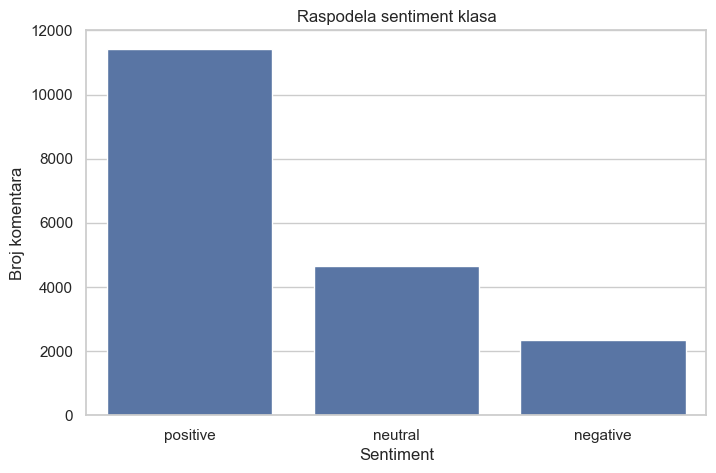

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Sentiment", order=df["Sentiment"].value_counts().index)
plt.title("Raspodela sentiment klasa")
plt.xlabel("Sentiment")
plt.ylabel("Broj komentara")
plt.show()

## Ciscenje podataka

In [9]:
df = df.dropna(subset=["Comment"])
df = df.drop_duplicates()

print("Nova dimenzija dataseta:", df.shape)

Nova dimenzija dataseta: (17874, 2)


In [10]:
print("Nedostajuce vrednosti:")
print(df.isnull().sum())

print("\nDuplikati:")
print(df.duplicated().sum())

Nedostajuce vrednosti:
Comment      0
Sentiment    0
dtype: int64

Duplikati:
0


## Duzina komentara
Analiziramo duzinu komentara u broju reci.

In [11]:
df["comment_length"] = df["Comment"].apply(lambda x: len(x.split()))
df["comment_length"].describe()

count    17874.000000
mean        32.991664
std         45.526381
min          1.000000
25%         12.000000
50%         21.000000
75%         38.000000
max       1353.000000
Name: comment_length, dtype: float64

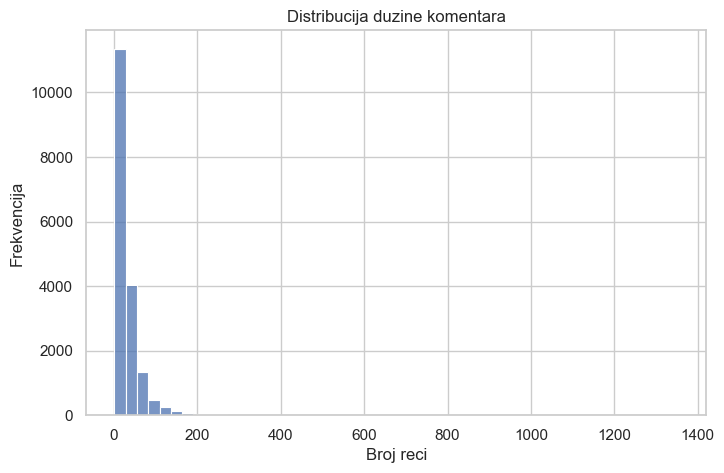

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["comment_length"], bins=50)
plt.title("Distribucija duzine komentara")
plt.xlabel("Broj reci")
plt.ylabel("Frekvencija")
plt.show()

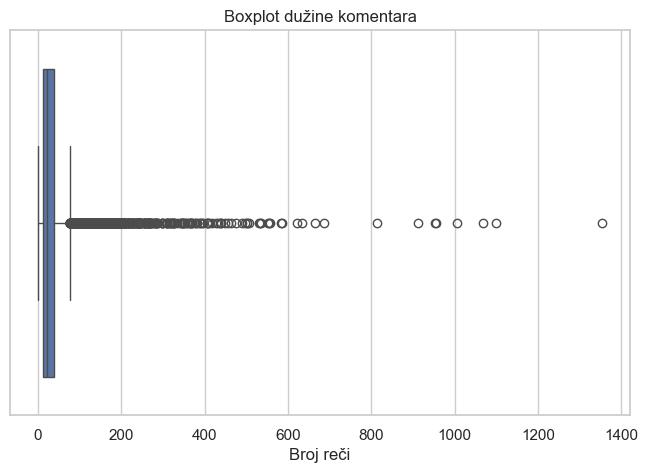

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["comment_length"])
plt.title("Boxplot dužine komentara")
plt.xlabel("Broj reči")
plt.show()

## Pretvaranje sentimenta u numericki oblik

In [14]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["sentiment_encoded"] = encoder.fit_transform(df["Sentiment"])

df.head()

,Comment,Sentiment,comment_length,sentiment_encoded
0,lets not forget that apple pay in 2014 require...,neutral,57,1
1,here in nz 50 of retailers don’t even have con...,negative,29,0
2,i will forever acknowledge this channel with t...,positive,31,2
3,whenever i go to a place that doesn’t take app...,negative,83,0
4,apple pay is so convenient secure and easy to ...,positive,26,2


Negative -> 0

Neutral -> 1

Positive -> 2

In [15]:
encoder.classes_

array(['negative', 'neutral', 'positive'], dtype=object)

## Preporcessing teksta

In [16]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)

    text = re.sub(r"[\U0001F600-\U0001F64F]", " emoji_happy ", text)
    text = re.sub(r"[\U0001F620-\U0001F62F]", " emoji_sad ", text)

    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    text = re.sub(r"[^a-z0-9\s!?']", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["Comment"] = df["Comment"].apply(clean_text)


In [17]:
df.head()

,Comment,Sentiment,comment_length,sentiment_encoded
0,lets not forget that apple pay in 2014 require...,neutral,57,1
1,here in nz 50 of retailers don t even have con...,negative,29,0
2,i will forever acknowledge this channel with t...,positive,31,2
3,whenever i go to a place that doesn t take app...,negative,83,0
4,apple pay is so convenient secure and easy to ...,positive,26,2


## Train / Test podela podataka

In [18]:
from sklearn.model_selection import train_test_split

X = df["Comment"]
y = df["sentiment_encoded"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)
 
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train_full
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 12154
Validation size: 2145
Test size: 3575


## Tokenizacija teksta
Pretvaramo tekst komentara u sekvence brojeva koje neuronska mreza moze da koristi.

In [19]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [20]:
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)


In [21]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)


In [22]:
print("Original:", X_train.iloc[0])
print("Sekvenca:", X_train_seq[0])

Original: this channel wants me to get more and more healthier every day
Sekvenca: [11, 176, 1077, 21, 3, 61, 39, 5, 39, 7295, 122, 137]


## Padding sekvenci
Komentari imaju razlicitu duzinu, zato ih dovodimo na istu duzinu.

In [23]:
max_len = 60

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

print("Train padded:", X_train_pad.shape)
print("Validation padded:", X_val_pad.shape)
print("Test padded:", X_test_pad.shape)


Train padded: (12154, 60)
Validation padded: (2145, 60)
Test padded: (3575, 60)


In [24]:
train_lengths = np.sum(X_train_pad != 0, axis=1)
val_lengths = np.sum(X_val_pad != 0, axis=1)
test_lengths = np.sum(X_test_pad != 0, axis=1)


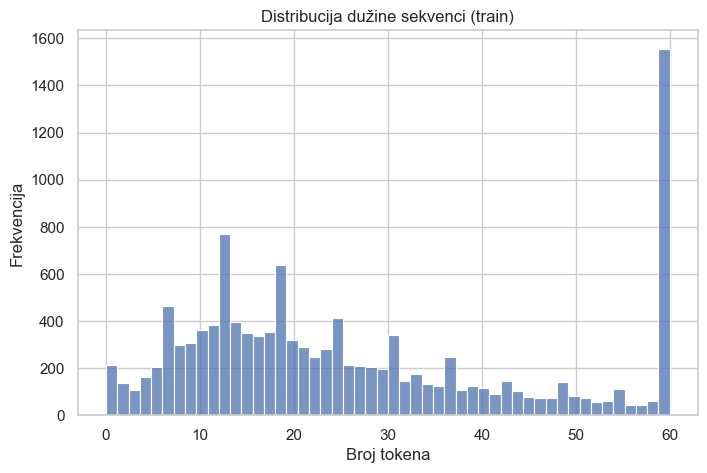

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(train_lengths, bins=50)
plt.title("Distribucija dužine sekvenci (train)")
plt.xlabel("Broj tokena")
plt.ylabel("Frekvencija")
plt.show()

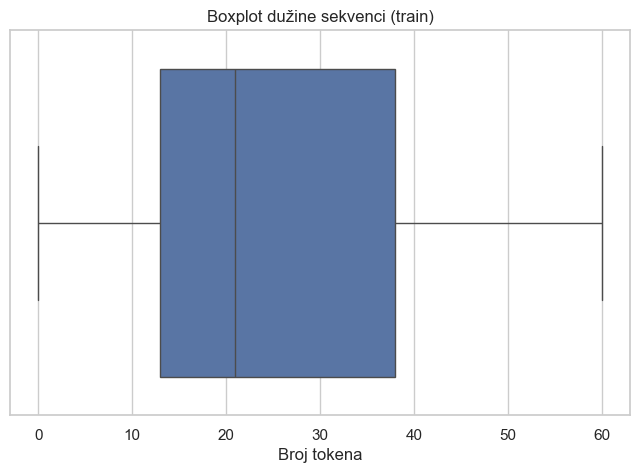

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x=train_lengths)
plt.title("Boxplot dužine sekvenci (train)")
plt.xlabel("Broj tokena")
plt.show()

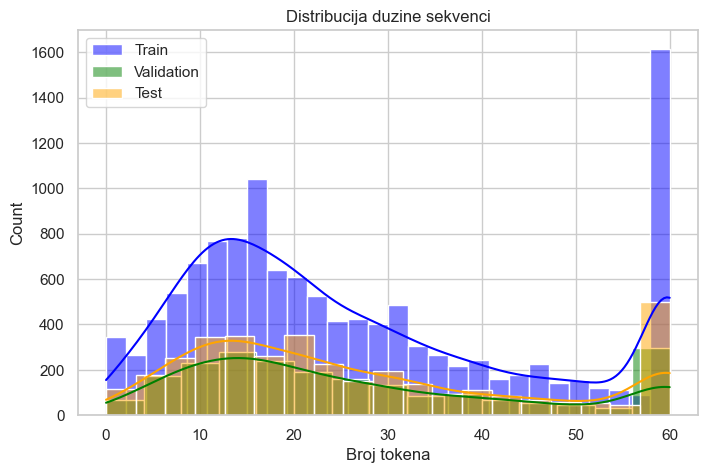

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(train_lengths, color="blue", label="Train", kde=True)
sns.histplot(val_lengths, color="green", label="Validation", kde=True)
sns.histplot(test_lengths, color="orange", label="Test", kde=True)
plt.legend()
plt.title("Distribucija duzine sekvenci")
plt.xlabel("Broj tokena")
plt.show()


## Uravnotežavanje klasa

In [28]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

print("Class weights:", class_weight_dict)

Class weights: {0: 2.570642978003384, 1: 1.3231003701284563, 2: 0.5390278516941636}


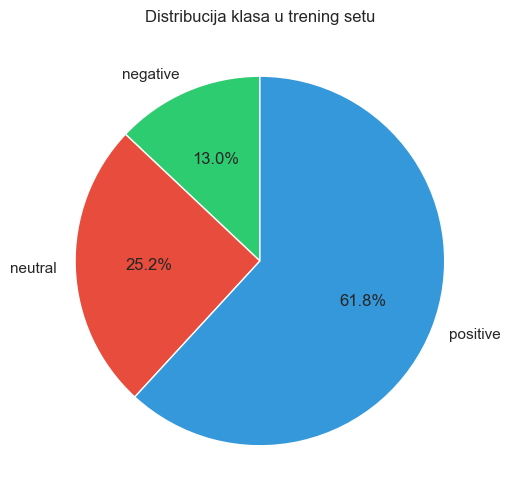

In [29]:
labels = encoder.classes_
counts = [sum(y_train == c) for c in range(len(labels))]

plt.figure(figsize=(6, 6))
plt.pie(counts, 
        labels=labels, 
        autopct="%1.1f%%",
        colors=["#2ecc71", "#e74c3c", "#3498db"],
        startangle=90)
plt.title("Distribucija klasa u trening setu")
plt.show()

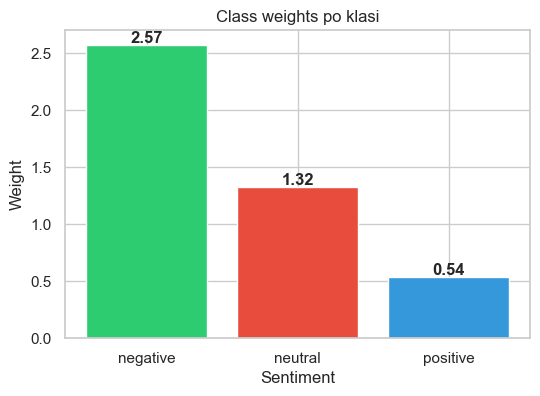

In [30]:
class_names = encoder.classes_
weights = list(class_weight_dict.values())

plt.figure(figsize=(6, 4))
plt.bar(class_names, weights, color=["#2ecc71", "#e74c3c", "#3498db"])
plt.title("Class weights po klasi")
plt.xlabel("Sentiment")
plt.ylabel("Weight")
for i, v in enumerate(weights):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")
plt.show()

## Kreiranje neuronske mreze

In [67]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    GRU,
    Dense,
    Dropout,
    Bidirectional,
    SpatialDropout1D,
    GlobalMaxPooling1D,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


In [68]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    SpatialDropout1D(0.30),

    Bidirectional(
        GRU(
            32,
            return_sequences=True,
            dropout=0.25,
            recurrent_dropout=0.25,
            kernel_regularizer=l2(1e-4)
        )
    ),

    GlobalMaxPooling1D(),
    Dense(32, activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.40),
    Dense(3, activation="softmax")
])


In [69]:
model.compile(
    optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Treniranje modela

In [70]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)


In [71]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=4,
    batch_size=128,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)


Epoch 1/4
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.4395 - loss: 1.0620 - val_accuracy: 0.5944 - val_loss: 0.9484 - learning_rate: 0.0010
Epoch 2/4
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.6633 - loss: 0.8598 - val_accuracy: 0.6783 - val_loss: 0.7689 - learning_rate: 0.0010
Epoch 3/4
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.7309 - loss: 0.7361 - val_accuracy: 0.7203 - val_loss: 0.7133 - learning_rate: 0.0010
Epoch 4/4
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.7917 - loss: 0.6076 - val_accuracy: 0.7422 - val_loss: 0.6611 - learning_rate: 0.0010


In [72]:
val_loss, val_acc = model.evaluate(X_val_pad, y_val, verbose=0)
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)

print("Validation accuracy:", val_acc)
print("Test accuracy:", test_acc)


Validation accuracy: 0.7421911358833313
Test accuracy: 0.7460139989852905


## Vizuelizacija treniranja modela

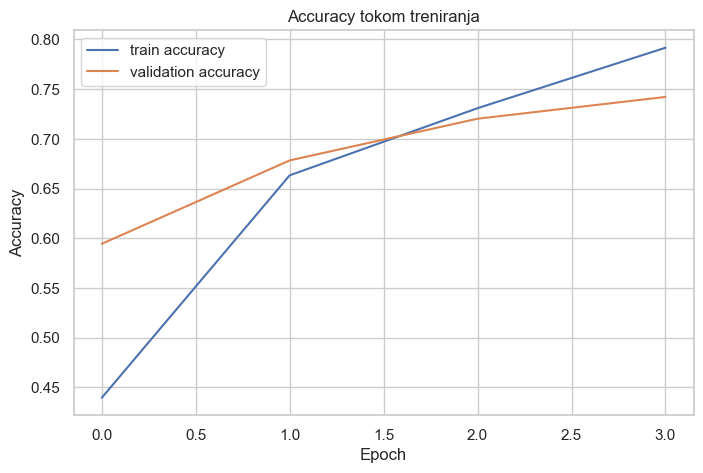

In [73]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.title("Accuracy tokom treniranja")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

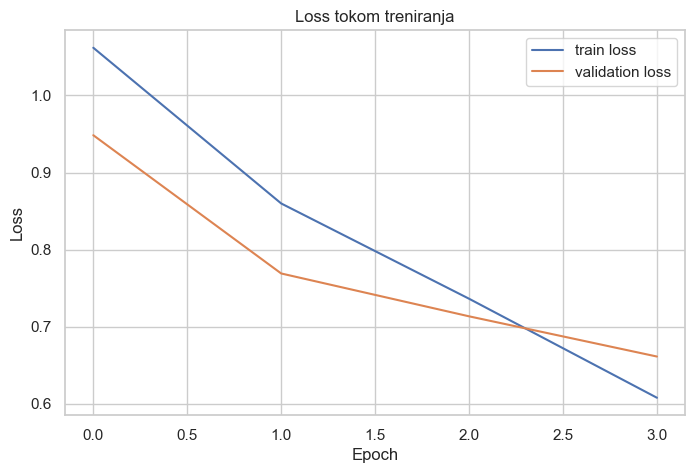

In [74]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.title("Loss tokom treniranja")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Predikcije modela

In [75]:
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


## Confusion matrix

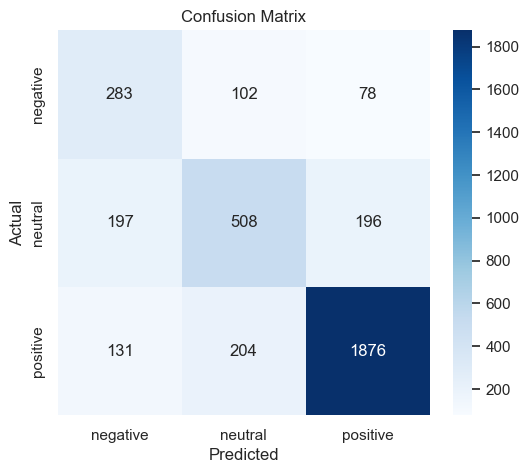

In [76]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Classification report

In [77]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=encoder.classes_))

              precision    recall  f1-score   support

    negative       0.46      0.61      0.53       463
     neutral       0.62      0.56      0.59       901
    positive       0.87      0.85      0.86      2211

    accuracy                           0.75      3575
   macro avg       0.65      0.67      0.66      3575
weighted avg       0.76      0.75      0.75      3575



## Testiranje modela na novom komentaru

In [78]:
def predict_sentiment(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")
    pred = model.predict(pad, verbose=0)
    label = np.argmax(pred, axis=1)[0]
    return encoder.classes_[label]


predict_sentiment("This video is amazing and very helpful")


'positive'

In [79]:
predict_sentiment("It's OK video")

'neutral'

In [80]:
predict_sentiment("This is the worst video ever")

'negative'

In [81]:
predict_sentiment("It's very useful, thanks.")

'positive'

In [82]:
predict_sentiment("Why are there no subtitles?")

'negative'